In [1]:
import tensorflow as tf
from tensorflow import keras
tf.__version__
keras.__version__

'2.5.0'

In [2]:
#load fashion mnist data
fashion_mnist=keras.datasets.fashion_mnist
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

4423680/4422102 [==============================] - 1s 0us/step


In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_test.shape

(10000, 28, 28)

In [7]:
#create a validation dataset containing 5000 images of the training set and scale all images
x_val,x_train=x_train[:5000]/255.0,x_train[5000:]/255.0
y_val,y_train=y_train[:5000],y_train[5000:]
x_test=x_test/255.0

In [8]:
#define class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

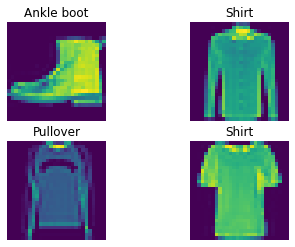

In [13]:
#show example images
import matplotlib.pyplot as plt
def show_four(first_index,second_index,third_index,forth_index):
    plt.subplot(2,2,1)
    plt.imshow(x_train[first_index])
    plt.title(class_names[y_train[first_index]])
    plt.axis("off")
    
    plt.subplot(2,2,2)
    plt.imshow(x_train[second_index])
    plt.title(class_names[y_train[second_index]]) 
    plt.axis("off")
    
    plt.subplot(2,2,3)
    plt.imshow(x_train[third_index])
    plt.title(class_names[y_train[third_index]])
    plt.axis("off")
    
    plt.subplot(2,2,4)
    plt.imshow(x_train[forth_index])
    plt.title(class_names[y_train[forth_index]])
    plt.axis("off")
    
show_four(3,15,100,123)

In [16]:
#Define the first simple model
model1=keras.Sequential()
model1.add(keras.layers.Flatten(input_shape=[28,28]))
model1.add(keras.layers.Dense(300,activation="relu"))
model1.add(keras.layers.Dense(100,activation="relu"))
model1.add(keras.layers.Dense(10,activation="softmax"))
model1.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_4 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_5 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [17]:
#Compile and trian model
model1.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])
history1=model1.fit(x_train,y_train,epochs=30,validation_data=(x_val,y_val))

Epoch 1/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.7321 - accuracy: 0.7596 - val_loss: 0.4989 - val_accuracy: 0.8312
Epoch 2/30
1719/1719 [==============================] - 4s 3ms/step - loss: 0.4907 - accuracy: 0.8292 - val_loss: 0.4585 - val_accuracy: 0.8454
Epoch 3/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4431 - accuracy: 0.8452 - val_loss: 0.4065 - val_accuracy: 0.8646
Epoch 4/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4171 - accuracy: 0.8536 - val_loss: 0.3999 - val_accuracy: 0.8652
Epoch 5/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3955 - accuracy: 0.8614 - val_loss: 0.3890 - val_accuracy: 0.8640
Epoch 6/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3792 - accuracy: 0.8658 - val_loss: 0.3694 - val_accuracy: 0.8730
Epoch 7/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3645 - accuracy: 0.8698 - val_loss: 0.3644 - val_accuracy:

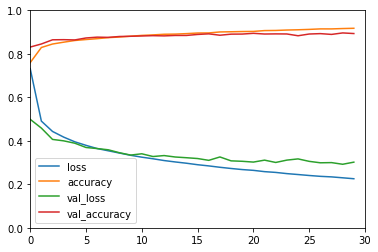

In [21]:
#Visualize training
import pandas as pd
pd.DataFrame(history1.history).plot()
plt.gca().set_ylim(0,1)
plt.gca().set_xlim(0,30)
plt.show()

In [22]:
#Continue training for 20 more epochs
history1_cont=model1.fit(x_train,y_train,epochs=20,validation_data=(x_val,y_val))

Epoch 1/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2224 - accuracy: 0.9195 - val_loss: 0.3141 - val_accuracy: 0.8880
Epoch 2/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2180 - accuracy: 0.9223 - val_loss: 0.2931 - val_accuracy: 0.8956
Epoch 3/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2145 - accuracy: 0.9226 - val_loss: 0.2956 - val_accuracy: 0.8928
Epoch 4/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2118 - accuracy: 0.9231 - val_loss: 0.2983 - val_accuracy: 0.8954
Epoch 5/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2080 - accuracy: 0.9253 - val_loss: 0.2917 - val_accuracy: 0.8922
Epoch 6/20
1719/1719 [==============================] - 5s 3ms/step - loss: 0.2060 - accuracy: 0.9260 - val_loss: 0.2940 - val_accuracy: 0.8930
Epoch 7/20
1719/1719 [==============================] - 6s 3ms/step - loss: 0.2017 - accuracy: 0.9272 - val_loss: 0.2901 - val_accuracy:

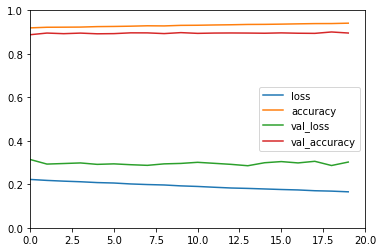

In [23]:
pd.DataFrame(history1_cont.history).plot()
plt.gca().set_ylim(0,1)
plt.gca().set_xlim(0,20)
plt.show()

In [24]:
#Evaluate on testing data
result1=model1.evaluate(x_test,y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.3340 - accuracy: 0.8876


The model predicts this image to show a Dress with 99.999% confidence


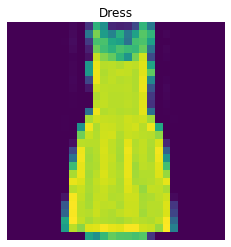

In [40]:
#Make predictions
import numpy as np
def eval_model1(index):
    img=x_test[index]
    predictions=model1.predict(x_test)
    true_label=y_test[index]
    pred_array=predictions[index]
    pred_index=np.argmax(pred_array)
    pred_str=class_names[pred_index]
    confidence=pred_array[pred_index]*100
    
    plt.imshow(img)
    plt.axis("off")
    plt.title(class_names[true_label])
    
    print("The model predicts this image to show a {} with {}% confidence".format(pred_str,np.round(confidence,3)))

eval_model1(330)

In [41]:
model1.save("fashion_mnist")

INFO:tensorflow:Assets written to: fashion_mnist/assets
